# 04 — 3D Geologic Model (Spangler 2024)

**Series:** Tribal Soils and Geology

---

## The Western South Dakota 3D Geologic Model

Spangler (2024) published the first regional-scale volumetric 3D geologic
model of western South Dakota as a USGS data release (DOI: 10.5066/P9LK4QHJ).
The model covers all of western South Dakota from west of the Missouri River
to the Wyoming border — including Pine Ridge and Rosebud entirely.

The model provides 25 subsurface horizon rasters representing the top
elevation of each major stratigraphic unit, plus 35 fault surfaces.
These rasters allow us to compute, for any point on the reservations:

- **Depth to any formation** — how deep is the Ogallala aquifer here?
  Where is the Pierre Shale thick vs. thin?
- **Formation thickness** — subtract adjacent horizons to produce isopach maps
- **Fault locations** — where do faults potentially compartmentalize aquifers
  or create structural complexity?

This dataset has never been visualized in a Tribal land sovereignty context.
This notebook provides that first look.

**Required data:** `data/raw/geology/WSouthDakota3D.gdb/`
Download from: https://doi.org/10.5066/P9LK4QHJ

In [24]:
import sys
from pathlib import Path
REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path: sys.path.insert(0, str(REPO_ROOT))
import warnings, numpy as np, pandas as pd
import geopandas as gpd, matplotlib.pyplot as plt
import matplotlib.patches as mpatches, contextily as ctx, yaml
from shapely.geometry import box
from src.constants import (
    CRS_GEOGRAPHIC, CRS_PROJECTED, CRS_WEB, REPO_ROOT as _REPO_ROOT,
    OUTPUTS_DIR, FIGURES_DIR, PINE_RIDGE_BBOX, ROSEBUD_BBOX,
    COMBINED_BBOX, STUDY_BBOX, WSD_3D_MODEL, WSD_STRATIGRAPHY, WSD_KEY_UNITS,
)
from src.loaders import load_tribal_boundaries
from src.sovereignty import print_data_acknowledgment, generate_citations, attach_provenance
warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline
with open(_REPO_ROOT/"config" / "config.yaml") as f: CONFIG = yaml.safe_load(f)
TEAL="#007A6E"; TEAL_LT="#E0F4F2"; GRAY="#566573"; TERRACOTTA="#C0392B"
def despine(ax):
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
primary = load_tribal_boundaries(["Pine Ridge","Rosebud"])
print(f"Ready. Nations: {len(primary)}")

Ready. Nations: 2


In [25]:
print_data_acknowledgment(source_keys=["usgs_3d_model"])

TRIBAL SOILS AND GEOLOGY — DATA GOVERNANCE ACKNOWLEDGMENT

This analysis uses data that describes the lands and subsurface
resources of the Oceti Sakowin — the Lakota, Dakota, and Nakota
peoples. This data is governed by the following frameworks:

OCAP®  : Tribal Nations have the right to Ownership, Control,
         Access, and Possession of data about their lands,
         including subsurface geological and soil data.
         Reference: https://fnigc.ca/ocap-training/

CARE   : Data use must deliver Collective Benefit to Indigenous
         peoples, respect their Authority to Control, uphold
         Responsibility to communities, and center Ethics.
         Reference: https://www.gida-global.org/care

FAIR   : Data is Findable, Accessible, Interoperable, Reusable.
         FAIR governs technical standards; CARE and OCAP® govern
         the ethical obligations FAIR alone does not address.
         Reference: https://www.go-fair.org/fair-principles/

IEEE 2890-2025 : Recommended Pr

---
## 1. Load Model Metadata and Boundary

In [26]:
from src.loaders import (
    load_wsd_3d_model_boundary, load_wsd_fault_points,
    load_wsd_model_units, load_wsd_horizon_raster,
)

# Model boundary
print("Loading 3D model boundary...")
model_boundary = load_wsd_3d_model_boundary()

if model_boundary.empty:
    print()
    print("WSouthDakota3D.gdb not found.")
    print("Download from: https://doi.org/10.5066/P9LK4QHJ")
    print("  Files needed: WSouthDakota3D.gdb.zip, WSD_NonspatialTables.zip")
    print("  Extract to: data/raw/geology/")
else:
    print(f"Model boundary loaded: {len(model_boundary)} polygon(s)")
    bb = model_boundary.total_bounds
    print(f"Extent: {bb[0]:.2f}W, {bb[1]:.2f}N to {bb[2]:.2f}E, {bb[3]:.2f}N")

# Model unit descriptions
print()
print("Loading model unit descriptions...")
model_units = load_wsd_model_units()
if not model_units.empty:
    print(f"Model units table: {len(model_units)} rows, {len(model_units.columns)} columns")
    print(f"Columns: {model_units.columns.tolist()}")
    print(model_units.head(5).to_string())

Loading 3D model boundary...
Model boundary loaded: 1 polygon(s)
Extent: -104.06W, 43.00N to -98.50E, 45.95N

Loading model unit descriptions...


C:\Users\gekek\AppData\Local\Temp\ipykernel_32112\1011367883.py:24: UserWarning: WSD_NonspatialTables not found in data/raw/geology/. Download from https://doi.org/10.5066/P9LK4QHJ
  model_units = load_wsd_model_units()


In [27]:
# Fault points
print("Loading fault surfaces...")
faults = load_wsd_fault_points()

if not faults.empty:
    print(f"Fault points loaded: {len(faults):,}")
    print(f"Columns: {faults.columns.tolist()}")
    if "Name" in faults.columns or "name" in faults.columns:
        name_col = "Name" if "Name" in faults.columns else "name"
        print(f"\nFault names:")
        print(faults[name_col].value_counts().head(15).to_string())
else:
    print("Fault data not loaded download the GDB first.")

Loading fault surfaces...
Fault points loaded: 147,352
Columns: ['Type', 'Symbol', 'Label', 'LocationConfidenceMeters', 'PlotAtScale', 'MapUnit', 'DataSourceID', 'Notes', 'FaultPoints_ID', 'x', 'y', 'z', 'ProbableFaultType', 'Informal_FaultModelName', 'geometry']


In [28]:
from src.constants import WSD_3D_MODEL
print("Tables path:", WSD_3D_MODEL["tables_path"])
print("Exists:", WSD_3D_MODEL["tables_path"].exists())

geology_dir = REPO_ROOT / "data" / "raw" / "geology"
print("\nAll contents of data/raw/geology/:")
for item in sorted(geology_dir.rglob("*")):
    print(f"  {item.relative_to(geology_dir)}")

Tables path: C:\Users\gekek\Documents\tribal-soils-geology\data\raw\geology\WSD_NonspatialTables
Exists: False

All contents of data/raw/geology/:
  NonspatialTables
  NonspatialTables\DataSources.xlsx
  NonspatialTables\DescriptionOfModelUnits.xlsx
  NonspatialTables\EntityAndAttribute_DataDictionary.xlsx
  NonspatialTables\Glossary.xlsx
  NonspatialTables\WSouthDakotaInputsSummaryTable.xlsx
  Shapefiles
  Shapefiles\ContactsAndFaults.cpg
  Shapefiles\ContactsAndFaults.dbf
  Shapefiles\ContactsAndFaults.prj
  Shapefiles\ContactsAndFaults.sbn
  Shapefiles\ContactsAndFaults.sbx
  Shapefiles\ContactsAndFaults.shp
  Shapefiles\ContactsAndFaults.shp.xml
  Shapefiles\ContactsAndFaults.shx
  Shapefiles\Fault_Points.cpg
  Shapefiles\Fault_Points.dbf
  Shapefiles\Fault_Points.prj
  Shapefiles\Fault_Points.sbn
  Shapefiles\Fault_Points.sbx
  Shapefiles\Fault_Points.shp
  Shapefiles\Fault_Points.shp.xml
  Shapefiles\Fault_Points.shx
  Shapefiles\MapUnitPolys.cpg
  Shapefiles\MapUnitPolys.dbf
  S

---
## 2. Model Extent Over Tribal Boundaries

C:\Users\gekek\AppData\Local\Temp\ipykernel_32112\3698111904.py:32: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=9, loc="lower left", framealpha=0.9)


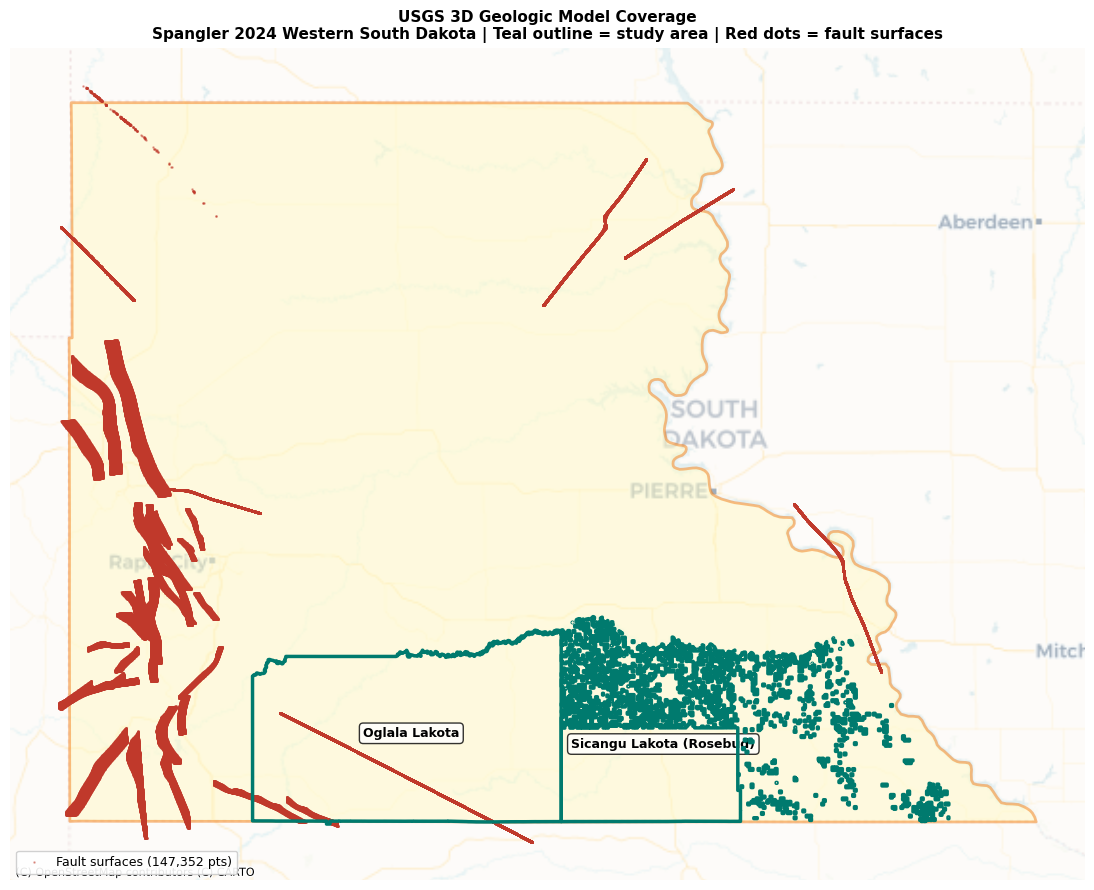

In [29]:
fig, ax = plt.subplots(figsize=(12, 9))

if not model_boundary.empty:
    model_boundary.to_crs(CRS_WEB).plot(
        ax=ax, facecolor="#FFF9C4", edgecolor="#F57F17",
        linewidth=2, alpha=0.5, zorder=2, label="3D Model extent"
    )

primary.to_crs(CRS_WEB).plot(
    ax=ax, facecolor="none", edgecolor=TEAL,
    linewidth=2.5, zorder=4, label="Pine Ridge / Rosebud"
)

if not faults.empty:
    faults.to_crs(CRS_WEB).plot(
        ax=ax, color=TERRACOTTA, marker=".", markersize=3,
        alpha=0.4, zorder=3, label=f"Fault surfaces ({len(faults):,} pts)"
    )

for _, row in primary.iterrows():
    c = row.geometry.centroid
    c3857 = gpd.GeoSeries([c], crs=CRS_GEOGRAPHIC).to_crs(CRS_WEB).iloc[0]
    ax.annotate(row["common_name"], (c3857.x, c3857.y), ha="center",
                fontsize=9, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager, alpha=0.5)
except Exception: pass

ax.set_axis_off()
ax.legend(fontsize=9, loc="lower left", framealpha=0.9)
ax.set_title(
    "USGS 3D Geologic Model Coverage\n"
    "Spangler 2024 Western South Dakota | "
    "Teal outline = study area | Red dots = fault surfaces",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "04_3d_model_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 3. Depth-to-Formation Maps

In [30]:
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.plot import show as rio_show
from shapely.geometry import mapping
import numpy as np

# This cell computes depth to a key horizon (Ogallala Group — the aquifer)
# by subtracting the horizon elevation raster from a DEM

KEY_HORIZON = "Ogallala Group"   # change to explore other formations

print(f"Attempting to load horizon raster: {KEY_HORIZON}")
horizon_ds = load_wsd_horizon_raster(KEY_HORIZON)

if horizon_ds is None:
    print()
    print("Horizon raster not loaded. Possible reasons:")
    print("  1. GDB not downloaded (see instructions in cell 1)")
    print("  2. Unit name does not match DescriptionOfModelUnits exactly")
    print()
    print("Available horizon names from model units table:")
    if not model_units.empty:
        name_cols = [c for c in model_units.columns
                     if "name" in c.lower() or "unit" in c.lower()]
        if name_cols:
            print(model_units[name_cols[0]].tolist())
    print()
    print("To explore the GDB layers directly:")
    print("  import fiona")
    print("  print(fiona.listlayers(str(WSD_3D_MODEL['gdb_path'])))")
else:
    print(f"Horizon raster loaded: {KEY_HORIZON}")
    print(f"  CRS: {horizon_ds.crs}")
    print(f"  Shape: {horizon_ds.height} x {horizon_ds.width}")
    print(f"  Bounds: {horizon_ds.bounds}")
    data = horizon_ds.read(1, masked=True)
    print(f"  Elevation range: {data.min():.1f} to {data.max():.1f} m")
    horizon_ds.close()

Attempting to load horizon raster: Ogallala Group

Horizon raster not loaded. Possible reasons:
  1. GDB not downloaded (see instructions in cell 1)
  2. Unit name does not match DescriptionOfModelUnits exactly

Available horizon names from model units table:

To explore the GDB layers directly:
  import fiona
  print(fiona.listlayers(str(WSD_3D_MODEL['gdb_path'])))


C:\Users\gekek\AppData\Local\Temp\ipykernel_32112\3733870821.py:13: UserWarning: Could not open horizon raster 'Ogallala Group': 'OpenFileGDB:C:\Users\gekek\Documents\tribal-soils-geology\data\raw\geology\WSouthDakota3D.gdb:Ogallala Group' does not exist in the file system, and is not recognized as a supported dataset name.. Check that the unit name matches DescriptionOfModelUnits exactly.
  horizon_ds = load_wsd_horizon_raster(KEY_HORIZON)


In [31]:
# List all layers in the GDB to find exact horizon names
from src.constants import WSD_3D_MODEL

gdb_path = WSD_3D_MODEL["gdb_path"]
if gdb_path.exists():
    try:
        import fiona
        layers = fiona.listlayers(str(gdb_path))
        print(f"GDB layers ({len(layers)} total):")
        for layer in sorted(layers):
            print(f"  {layer}")
    except Exception as e:
        print(f"Could not list GDB layers: {e}")
else:
    print("GDB not found at:", gdb_path)
    print("Download and extract from https://doi.org/10.5066/P9LK4QHJ")

GDB layers (9 total):
  DataSources
  DescriptionOfModelUnits
  FaultPoints
  GeoMaterialDict
  Glossary
  ModelBoundary
  fras_blk_SouthDakota_TopHellCreek
  fras_blk_WSouthDakota_TopPierreShale
  fras_blk_WSouthDakota_TopPreOgallala


---
## 4. Cross-Section Generator

In [32]:
# Define a transect line and extract horizon elevations along it
# This cell is structured to work once the GDB is available

import numpy as np
from shapely.geometry import LineString, Point

# Example transect: west to east across Pine Ridge
# Adjust these coordinates to define your transect of interest
TRANSECT_START = (-103.2, 43.0)   # (lon, lat) western end
TRANSECT_END   = (-101.6, 43.0)   # (lon, lat) eastern end
N_SAMPLE_POINTS = 50

# Build the transect sample points
lons = np.linspace(TRANSECT_START[0], TRANSECT_END[0], N_SAMPLE_POINTS)
lats = np.linspace(TRANSECT_START[1], TRANSECT_END[1], N_SAMPLE_POINTS)
transect_line = LineString(zip(lons, lats))

# Compute distance along transect in km
from pyproj import Geod
geod = Geod(ellps="WGS84")
distances_km = []
d = 0.0
for i in range(N_SAMPLE_POINTS):
    if i == 0:
        distances_km.append(0.0)
    else:
        _, _, dist = geod.inv(lons[i-1], lats[i-1], lons[i], lats[i])
        d += dist / 1000.0
        distances_km.append(d)

print(f"Transect defined:")
print(f"  Start: {TRANSECT_START} (W)")
print(f"  End:   {TRANSECT_END} (E)")
print(f"  Length: {distances_km[-1]:.1f} km")
print(f"  Sample points: {N_SAMPLE_POINTS}")
print()
print("To extract horizon elevations along this transect:")
print("  1. Ensure WSouthDakota3D.gdb is in data/raw/geology/")
print("  2. Load each horizon raster with load_wsd_horizon_raster(unit_name)")
print("  3. Sample the raster at each transect point using rasterio.sample()")
print("  4. Subtract from DEM elevation to get depth")
print()
print("The cell below shows the cross-section plotting framework,")
print("ready to populate with extracted horizon elevations.")

Transect defined:
  Start: (-103.2, 43.0) (W)
  End:   (-101.6, 43.0) (E)
  Length: 130.5 km
  Sample points: 50

To extract horizon elevations along this transect:
  1. Ensure WSouthDakota3D.gdb is in data/raw/geology/
  2. Load each horizon raster with load_wsd_horizon_raster(unit_name)
  3. Sample the raster at each transect point using rasterio.sample()
  4. Subtract from DEM elevation to get depth

The cell below shows the cross-section plotting framework,
ready to populate with extracted horizon elevations.


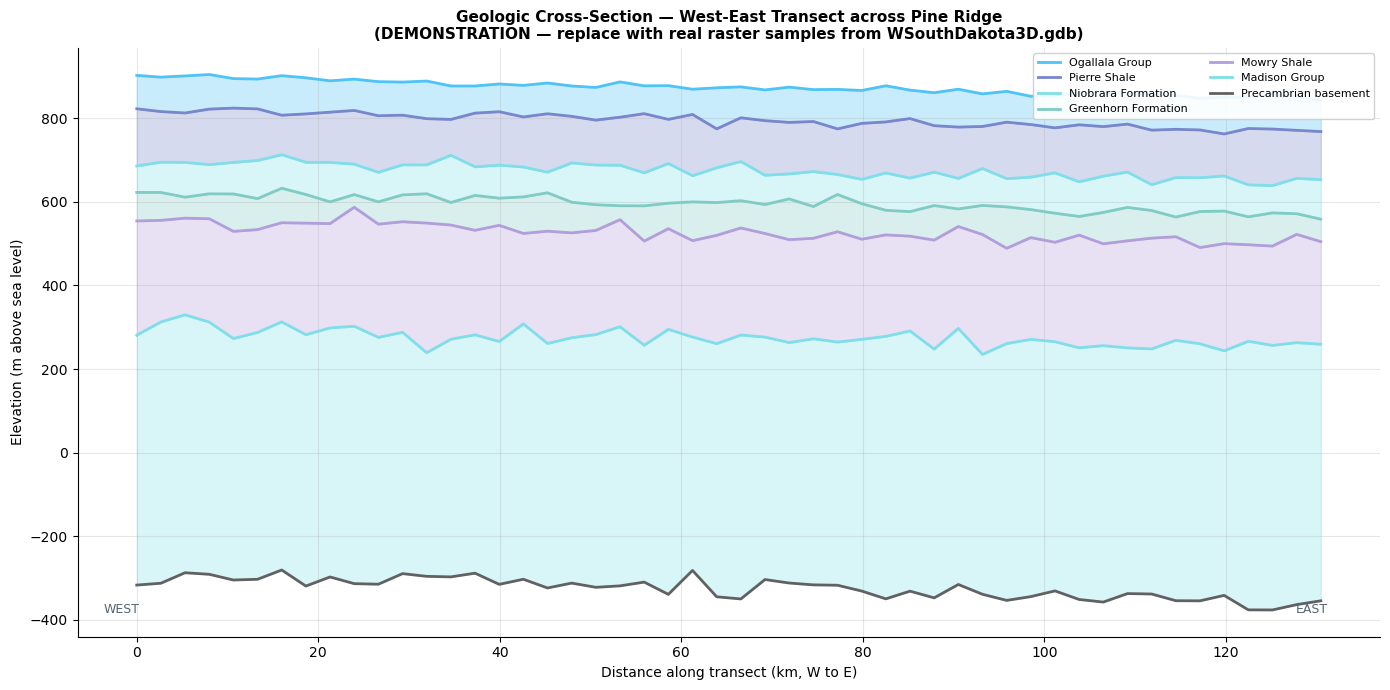

NOTE: This uses synthetic data for layout demonstration.
Replace demo_horizons with real raster samples once GDB is in data/raw/geology/


In [33]:
# Cross-section plotting framework
# Populate horizon_elevations dict from raster sampling when GDB is available

# Example structure — fill with real data from raster sampling
# horizon_elevations = {
#     "Ogallala Group": [array of elevations at each transect point],
#     "Pierre Shale":   [array of elevations at each transect point],
#     ...
# }

# Synthetic demonstration (replace with real raster samples)
np.random.seed(42)
base_elev = 900 - np.linspace(0, 50, N_SAMPLE_POINTS)  # slight eastward dip
demo_horizons = {
    "Ogallala Group":    base_elev + np.random.normal(0, 5, N_SAMPLE_POINTS),
    "Pierre Shale":      base_elev - 80  + np.random.normal(0, 8, N_SAMPLE_POINTS),
    "Niobrara Formation":base_elev - 200 + np.random.normal(0, 10, N_SAMPLE_POINTS),
    "Greenhorn Formation":base_elev - 280+ np.random.normal(0, 10, N_SAMPLE_POINTS),
    "Mowry Shale":       base_elev - 350 + np.random.normal(0, 12, N_SAMPLE_POINTS),
    "Madison Group":     base_elev - 600 + np.random.normal(0, 15, N_SAMPLE_POINTS),
    "Precambrian basement":base_elev-1200+ np.random.normal(0, 20, N_SAMPLE_POINTS),
}

HORIZON_COLORS = {
    "Ogallala Group":     "#4FC3F7",
    "Pierre Shale":       "#7986CB",
    "Niobrara Formation": "#80DEEA",
    "Greenhorn Formation":"#80CBC4",
    "Mowry Shale":        "#B39DDB",
    "Madison Group":      "#80DEEA",
    "Precambrian basement":"#616161",
}

fig, ax = plt.subplots(figsize=(14, 7))
horizon_names = list(demo_horizons.keys())

for i, (unit, elev) in enumerate(demo_horizons.items()):
    color = HORIZON_COLORS.get(unit, "#CCCCCC")
    ax.plot(distances_km, elev, color=color, linewidth=2, label=unit)
    # Fill between adjacent horizons
    if i < len(horizon_names) - 1:
        next_elev = demo_horizons[horizon_names[i+1]]
        ax.fill_between(distances_km, elev, next_elev,
                        color=color, alpha=0.3)

ax.set_xlabel("Distance along transect (km, W to E)", fontsize=10)
ax.set_ylabel("Elevation (m above sea level)", fontsize=10)
ax.set_title(
    f"Geologic Cross-Section — West-East Transect across Pine Ridge\n"
    f"(DEMONSTRATION — replace with real raster samples from WSouthDakota3D.gdb)",
    fontsize=11, fontweight="bold"
)
ax.legend(fontsize=8, loc="upper right", framealpha=0.9, ncol=2)
ax.text(0.02, 0.04, "WEST", transform=ax.transAxes, fontsize=9, color=GRAY)
ax.text(0.96, 0.04, "EAST", transform=ax.transAxes, fontsize=9, color=GRAY, ha="right")
ax.grid(alpha=0.3)
despine(ax)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "04_cross_section_demo.png", dpi=150, bbox_inches="tight")
plt.show()
print("NOTE: This uses synthetic data for layout demonstration.")
print("Replace demo_horizons with real raster samples once GDB is in data/raw/geology/")

---
## 5. Fault Map

C:\Users\gekek\AppData\Local\Temp\ipykernel_32112\2927629224.py:37: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=TEAL_LT, edgecolor=TEAL, label="Tribal boundaries"),


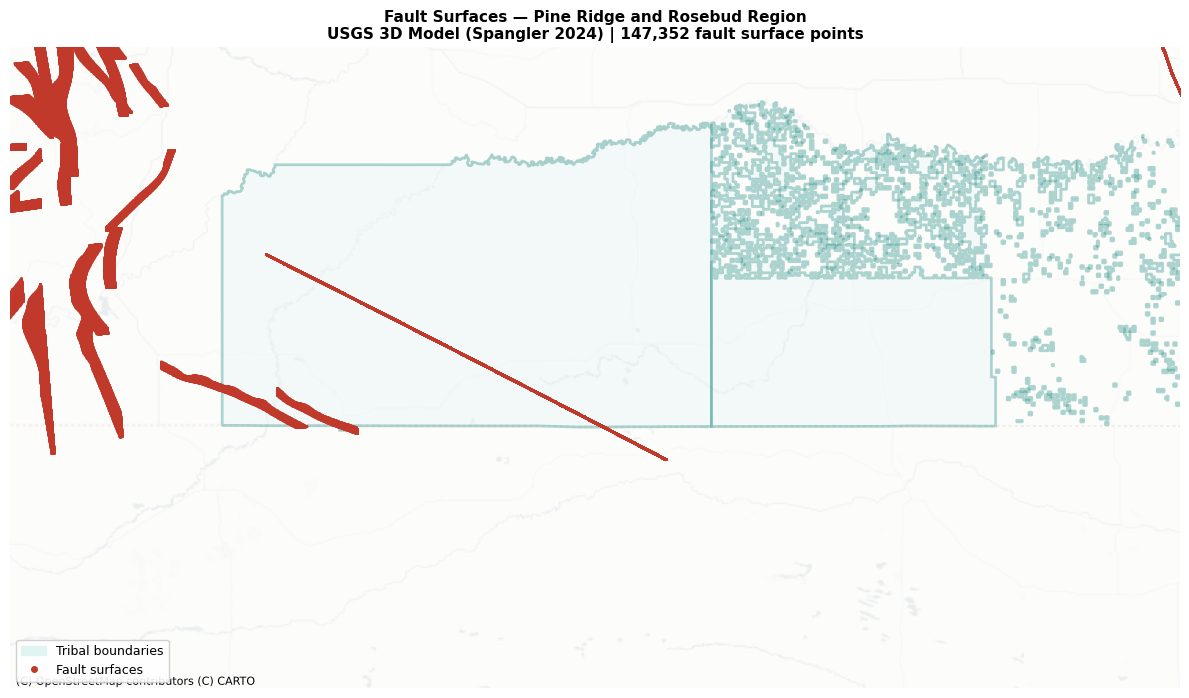

In [34]:
if not faults.empty:
    fig, ax = plt.subplots(figsize=(12, 9))

    primary.to_crs(CRS_WEB).plot(
        ax=ax, facecolor=TEAL_LT, edgecolor=TEAL,
        linewidth=2, alpha=0.3, zorder=2
    )
    faults.to_crs(CRS_WEB).plot(
        ax=ax, color=TERRACOTTA, marker=".", markersize=4,
        alpha=0.6, zorder=3
    )

    # Focus extent on combined study area
    from shapely.geometry import box as sbox
    bbox_gdf = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy(
            [COMBINED_BBOX[0], COMBINED_BBOX[2]],
            [COMBINED_BBOX[1], COMBINED_BBOX[3]],
        ), crs=CRS_GEOGRAPHIC
    ).to_crs(CRS_WEB)
    xs, ys = bbox_gdf.geometry.x.values, bbox_gdf.geometry.y.values
    margin = 30_000
    ax.set_xlim(xs[0]-margin, xs[1]+margin)
    ax.set_ylim(ys[0]-margin, ys[1]+margin)

    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.5)
    except Exception: pass

    ax.set_axis_off()
    ax.set_title(
        f"Fault Surfaces — Pine Ridge and Rosebud Region\n"
        f"USGS 3D Model (Spangler 2024) | {len(faults):,} fault surface points",
        fontsize=11, fontweight="bold"
    )
    legend_el = [
        mpatches.Patch(color=TEAL_LT, edgecolor=TEAL, label="Tribal boundaries"),
        plt.Line2D([0],[0], marker=".", color=TERRACOTTA, markersize=8,
                   linestyle="", label="Fault surfaces"),
    ]
    ax.legend(handles=legend_el, fontsize=9, loc="lower left", framealpha=0.9)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "04_fault_map.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Fault data not loaded. Download GDB to enable this visualization.")

---
## 6. Model Uncertainty — A Note for Users

The Spangler (2024) model README contains critical guidance on uncertainty.
Key points that geologists and resource managers should be aware of:

**Scale:** The model is regional-scale. Subsurface horizons are constrained
by well log control points that are widely spaced. Local variability in
formation depth and thickness is not captured.

**Well log density:** The density of control wells varies across the study
area. Areas with fewer wells have greater uncertainty in horizon elevations.
Pine Ridge and Rosebud have relatively sparse well log records compared to
surrounding areas — a monitoring equity gap that directly degrades model
accuracy on Tribal lands.

**Faults:** The 35 modeled fault surfaces represent interpreted fault traces,
not precisely located structures. Fault geometry at depth carries significant
uncertainty.

**Use:** The model is appropriate for regional resource assessment, aquifer
characterization, and geologic framework studies. It is not a substitute for
local-scale investigation (test wells, geophysical surveys, surface mapping).

**How Tribal data helps:** Every well log drilled on Pine Ridge or Rosebud,
formatted to the `well_log_template.xlsx` standard, directly reduces model
uncertainty. The template is designed to produce data compatible with USGS
well log databases.

In [35]:
print(generate_citations(["usgs_3d_model"]))

DATA CITATIONS

USGS 3D Geological Model of Western South Dakota
  Spangler, L.R., 2024, Digital data for a 3D Geological Model of western South Dakota, USA: U.S. Geological Survey data release, https://doi.org/10.5066/P9LK4QHJ.
  https://doi.org/10.5066/P9LK4QHJ
  Steward: US Geological Survey, Rocky Mountain Region | License: CC0 1.0 Universal (Public Domain)

TERRITORIAL PROVENANCE
  1868 Fort Laramie Treaty — Oceti Sakowin territory, including the Great Sioux Reservation
  The lands of Pine Ridge and Rosebud Reservations are the sovereign territory of the Oglala Lakota and Sicangu Lakota peoples respectively. Federal and state geological surveys conducted on these lands do not transfer authority over subsurface resources to federal agencies.
  United States v. Sioux Nation of Indians, 448 U.S. 371 (1980). The Sioux Nations have declined financial compensation, maintaining that the land was never legally transferred.

GOVERNANCE FRAMEWORKS: OCAP® | CARE | FAIR | IEEE 2890-2025
  OCA